<a href="https://colab.research.google.com/github/TomoyoTashiro/dev/blob/feature-tashiro/%E9%9B%A2%E5%8F%8D%E4%BA%88%E6%B8%AC_20250530.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

現在離反していない人の、90日後の離反を予測

●データ作成(共有クエリ)  
https://console.cloud.google.com/bigquery?hl=ja&project=satudoradwh&ws=!1m7!1m6!12m5!1m3!1ssatudoradwh!2sasia-northeast1!3sac8652e7-cac2-463f-8cc2-1c8a0b67014f!2e1&invt=AbtvoQ  
test.rihanyosoku_tashiro  
  
●Case1の可視化  
[Tableauダッシュボードリンク](https://prod-apnortheast-a.online.tableau.com/#/site/satudora/workbooks/3101956/views)

●特徴量の検討  
https://docs.google.com/spreadsheets/d/1nkjaQ06FWruWHG5fSNviRtKD0CkBudqpzHCHj0uYWWk/edit?gid=0#gid=0

In [ ]:
import numpy as np
import pandas as pd
from pandas_gbq import to_gbq
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score,mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from imblearn.under_sampling import RandomUnderSampler

import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from google.colab import auth

auth.authenticate_user()

## データ読み込み

In [ ]:
project_id = "satudoradwh"
client = bigquery.Client(project=project_id)

query = "SELECT *except(ezocaID) FROM test.rihanyosoku_tashiro"

df = client.query(query).to_dataframe()

# 文字列だけど本当は数値である列に対して変換
for col in df.columns:
    if df[col].dtype == 'object' and col.startswith('pct_'):
        try:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        except:
            pass  # 数値じゃない列（カテゴリなど）はスルー

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 926217 entries, 0 to 926216
Data columns (total 28 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   era                              926217 non-null  object 
 1   Gender                           926217 non-null  object 
 2   zipcode_prefix                   926217 non-null  object 
 3   kaisu_60d                        926217 non-null  Int64  
 4   amount_60d                       926217 non-null  Int64  
 5   avg_basket_size_60d              926217 non-null  float64
 6   TotalPoints                      926217 non-null  Int64  
 7   favorite_time_slot               926216 non-null  object 
 8   weekday_visit_ratio              926217 non-null  float64
 9   store_last_visit                 926217 non-null  object 
 10  store_most_visit                 926217 non-null  object 
 11  pct_1                            926217 non-null  float64
 12  pc

In [ ]:
# 郵便番号 上位50だけ残す (600種類ほど存在) 100にするとテストデータで1サンプルの郵便番号が目立った
zip_counts = df['zipcode_prefix'].value_counts()
top_zips = zip_counts.head(50).index.tolist()
df['zipcode_prefix'] = df['zipcode_prefix'].apply(lambda x: x if x in top_zips else 'その他')
df['zipcode_prefix'] = df['zipcode_prefix'].apply(lambda x: 'その他' if x=='' else x)

df_copy = df.copy()

## データの確認(2回目からは飛ばしてOK)

In [ ]:
#df.head(10)

In [ ]:
df['label'].value_counts()

,count
label,
0,794057
1,132160


In [ ]:
df['Gender'].value_counts()

,count
Gender,
女性,676182
男性,236862
不明,13173


In [ ]:
df['era'].value_counts()

,count
era,
50,198393
40,162586
60,155085
70,128759
30,96987
不明,84803
80,46463
20,42061
90,7318


array([[<Axes: title={'center': 'span'}>,
        <Axes: title={'center': 'kaisu_60d'}>,
        <Axes: title={'center': 'amount_60d'}>,
        <Axes: title={'center': 'avg_basket_size_60d'}>],
       [<Axes: title={'center': 'TotalPoints'}>,
        <Axes: title={'center': 'weekday_vistit_ratio'}>,
        <Axes: title={'center': 'pct_1'}>,
        <Axes: title={'center': 'pct_3'}>],
       [<Axes: title={'center': 'pct_4'}>,
        <Axes: title={'center': 'pct_19'}>,
        <Axes: title={'center': 'pct_22'}>,
        <Axes: title={'center': 'pct_23_16'}>],
       [<Axes: title={'center': 'pct_5_6'}>,
        <Axes: title={'center': 'pct_7'}>,
        <Axes: title={'center': 'pct_9'}>,
        <Axes: title={'center': 'pct_14_15'}>],
       [<Axes: title={'center': 'pct_2'}>,
        <Axes: title={'center': 'label'}>, <Axes: >, <Axes: >]],
      dtype=object)

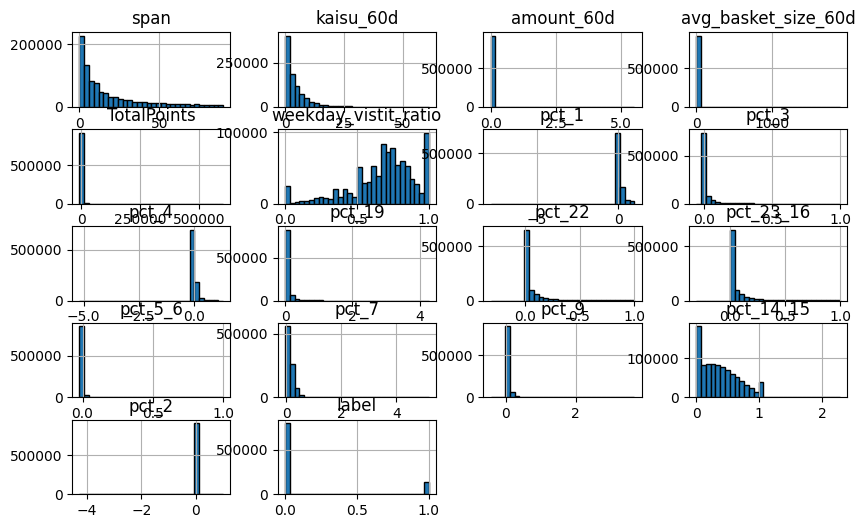

In [ ]:
# ヒストグラムを作成
df.hist(figsize=(10, 6), bins=30, edgecolor="black")

## LightGBM

### Case1 AUC:0.875  

In [ ]:
df = df_copy.copy()

categorical_cols = [ #カテゴリ変数
    'favorite_time_slot',
    'zipcode_prefix',
    'era',
    'Gender',
    'store_last_visit',
    'store_most_visit'
]

# 特徴量とラベルを定義
X = df.drop('label', axis=1)
y = df['label']

# 1 アンダーサンプリングの実行**
undersampler = RandomUnderSampler(sampling_strategy=0.5, random_state=42)  # 1:9 → 1:2 に調整
X_resampled, y_resampled = undersampler.fit_resample(X, y)

# アンダーサンプリング後のデータ分布を確認**
sampling_result = pd.DataFrame({'ラベル': ['0 (多数クラス)', '1 (少数クラス)'],
                                'データ数': [sum(y_resampled == 0), sum(y_resampled == 1)]})
sampling_result

,ラベル,データ数
0,0 (多数クラス),264320
1,1 (少数クラス),132160


In [ ]:
# 2 データの分割**
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# 3 カテゴリ変数を指定
dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols)
dtest  = lgb.Dataset(X_test, label=y_test, reference=dtrain, categorical_feature=categorical_cols)

for col in categorical_cols:# カテゴリ列を明示的に category 型に変換
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# 4 LightGBM モデルの定義（不均衡データ対応）**
model = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    random_state=42,
    n_estimators=100
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=10),
        lgb.log_evaluation(period=0)  # 表示抑制（0で非表示、10で10回ごと表示など）
    ],
    categorical_feature=categorical_cols
)

y_pred = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)
print(f"AUC: {auc:.4f}")
print('-----------')
y_pred_class = (y_pred >= 0.5).astype(int)
print(classification_report(y_test, y_pred_class))

[LightGBM] [Info] Number of positive: 105699, number of negative: 211485
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.063933 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5328
[LightGBM] [Info] Number of data points in the train set: 317184, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333242 -> initscore=-0.693559
[LightGBM] [Info] Start training from score -0.693559
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[79]	valid_0's auc: 0.885855
AUC: 0.8859
-----------
              precision    recall  f1-score   support

         0.0       0.86      0.85      0.86     52835
         1.0       0.71      0.72      0.72     26461

    accuracy                           0.81     79296
   macro avg       0.78      0.79      0.79     79296
weighted avg      

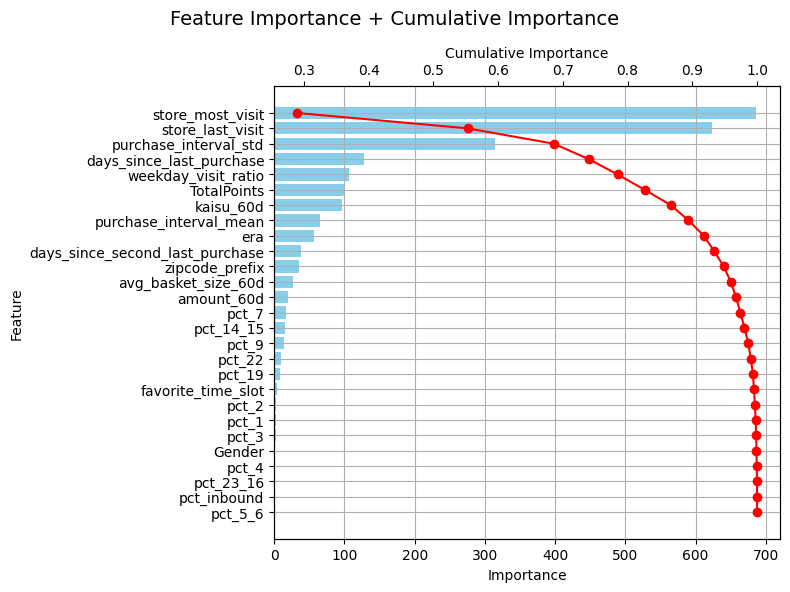

In [ ]:
# 特徴量の重要度を取得
feature_importances = model.feature_importances_
feature_names = X_train.columns

# データフレームに整理
importance_df = pd.DataFrame({'特徴量': feature_names, '重要度': feature_importances})
importance_df = importance_df.sort_values(by="重要度", ascending=False) #True)  # 重要度順に並べる
importance_df["重要度(%)"] = importance_df["重要度"] / importance_df["重要度"].sum()
importance_df["累積重要度"] = importance_df["重要度(%)"].cumsum()
importance_df = importance_df.sort_values(by="累積重要度", ascending=False)
importance_df1 = importance_df.copy() #★後ほど使うために残す

#グラフ化
fig, ax1 = plt.subplots(figsize=(8, 6))

# 左軸：棒グラフ（横）
ax1.barh(
    importance_df["特徴量"],
    importance_df["重要度"],
    color="skyblue",
    label="Importance"
)
ax1.set_xlabel("Importance")
ax1.set_ylabel("Feature")
ax1.grid(True)

# 右軸：累積重要度（折れ線）
ax2 = ax1.twiny()
ax2.plot(
    importance_df["累積重要度"],
    importance_df["特徴量"],
    color="red",
    marker="o",
    label="Cumulative Importance"
)
ax2.set_xlabel("Cumulative Importance")

# 凡例と仕上げ
fig.suptitle("Feature Importance + Cumulative Importance", fontsize=14)
plt.tight_layout()
plt.show()

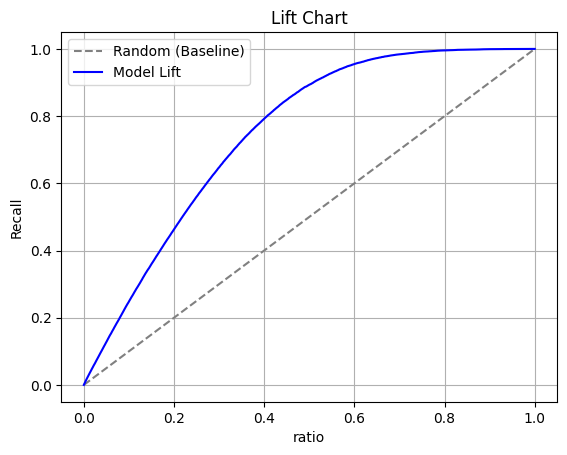

In [ ]:
#リフトチャート
lift_df = pd.DataFrame({
    "score": y_pred,
    "label": y_test.reset_index(drop=True)  # インデックス合わせ
})

# スコア順に並び替え
lift_df = lift_df.sort_values(by="score", ascending=False).reset_index(drop=True)

# 累積割合（上位何％まで）を計算
lift_df["percentile"] = (lift_df.index + 1) / len(lift_df)

# 累積で拾った離反者の割合
lift_df["cumulative_positives"] = lift_df["label"].cumsum()
total_positives = lift_df["label"].sum()
lift_df["recall_at_percentile"] = lift_df["cumulative_positives"] / total_positives

# ランダムモデルとの比較線（参考線）
plt.plot(lift_df["percentile"], lift_df["percentile"], linestyle='--', label='Random (Baseline)', color='gray')

# あなたのモデルのリフトカーブ
plt.plot(lift_df["percentile"], lift_df["recall_at_percentile"], label='Model Lift', color='blue')

plt.xlabel("ratio") #対象者の割合（上位）
plt.ylabel("Recall") #離反者の捕捉率
plt.title("Lift Chart")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
dataset = "test"
table = "rihanyosoku_tashiro_output"

df_output = X_test.copy()
df_output["score"] = y_pred
df_output["label"] = y_test.values  # 実ラベルも出すとよい
df_output["index"] = df_output.index  # インデックスをIDとして使う場合

to_gbq(
    df_output,
    destination_table=f"{dataset}.{table}",
    project_id=project_id,
    if_exists="replace"
)

100%|██████████| 1/1 [00:00<00:00, 9489.38it/s]


### Case2 zipcodeなし

In [ ]:
df = df_copy.copy()
del df['zipcode_prefix']

categorical_cols = [
    'favorite_time_slot',
#    'zipcode_prefix',
    'era',
    'Gender',
    'store_last_visit',
    'store_most_visit'
]

# 特徴量とラベルを定義
X = df.drop('label', axis=1)
y = df['label']

# 1 アンダーサンプリングの実行
undersampler = RandomUnderSampler(sampling_strategy=0.5, random_state=42)  # 1:9 → 1:2 に調整
X_resampled, y_resampled = undersampler.fit_resample(X, y)

# 2 アンダーサンプリング後のデータ分布を確認
sampling_result = pd.DataFrame({'ラベル': ['0 (多数クラス)', '1 (少数クラス)'],
                                'データ数': [sum(y_resampled == 0), sum(y_resampled == 1)]})
# 3 データの分割**
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# 4 カテゴリ変数を指定
dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols)
dtest  = lgb.Dataset(X_test, label=y_test, reference=dtrain, categorical_feature=categorical_cols)

for col in categorical_cols:# カテゴリ列を明示的に category 型に変換
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# 5 LightGBM モデルの定義（不均衡データ対応）
model = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    random_state=42,
    n_estimators=100
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=10),
        lgb.log_evaluation(period=0)  # 表示抑制（0で非表示、10で10回ごと表示など）
    ],
    categorical_feature=categorical_cols
)

y_pred = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)
print(f"AUC: {auc:.4f}")
print('-----------')
y_pred_class = (y_pred >= 0.5).astype(int)
print(classification_report(y_test, y_pred_class))

[LightGBM] [Info] Number of positive: 105699, number of negative: 211485
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.064725 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5278
[LightGBM] [Info] Number of data points in the train set: 317184, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333242 -> initscore=-0.693559
[LightGBM] [Info] Start training from score -0.693559
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[75]	valid_0's auc: 0.885683
AUC: 0.8857
-----------
              precision    recall  f1-score   support

         0.0       0.86      0.85      0.86     52835
         1.0       0.71      0.72      0.72     26461

    accuracy                           0.81     79296
   macro avg       0.78      0.79      0.79     79296
weighted avg      

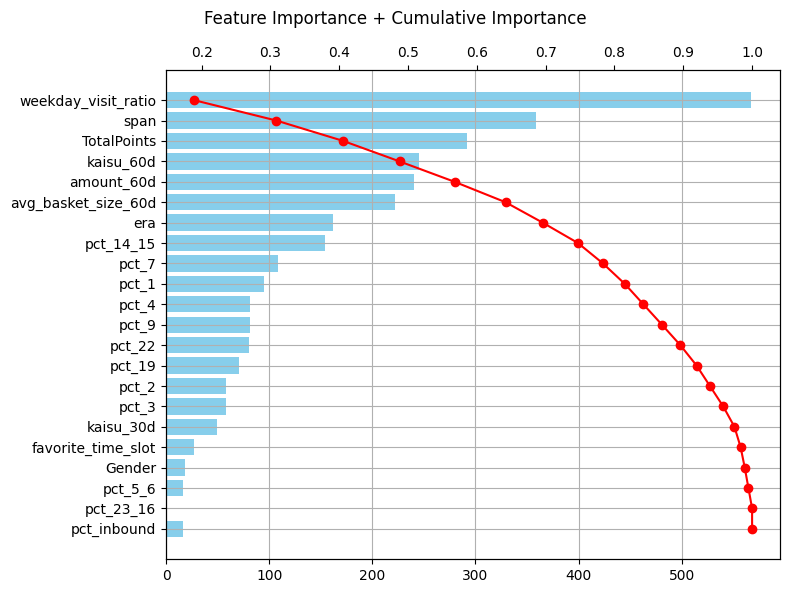

In [ ]:
# 特徴量の重要度をグラフ化
feature_importances = model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({'特徴量': feature_names, '重要度': feature_importances})
importance_df = importance_df.sort_values(by="重要度", ascending=False)
importance_df["重要度(%)"] = importance_df["重要度"] / importance_df["重要度"].sum()
importance_df["累積重要度"] = importance_df["重要度(%)"].cumsum()
importance_df = importance_df.sort_values(by="累積重要度", ascending=False)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.barh(
    importance_df["特徴量"],
    importance_df["重要度"],
    color="skyblue",
    label="Importance"
)
ax1.grid(True)

ax2 = ax1.twiny()
ax2.plot(
    importance_df["累積重要度"],
    importance_df["特徴量"],
    color="red",
    marker="o",
    label="Cumulative Importance"
)

# 凡例と仕上げ
fig.suptitle("Feature Importance + Cumulative Importance", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
dataset = "test"
table = "rihanyosoku_tashiro_output2"

df_output = X_test.copy()
df_output["score"] = y_pred
df_output["label"] = y_test.values
df_output["index"] = df_output.index

to_gbq(
    df_output,
    destination_table=f"{dataset}.{table}",
    project_id=project_id,
    if_exists="replace"
)

100%|██████████| 1/1 [00:00<00:00, 9118.05it/s]


### Case3 weekday_visit_ratioなし

In [ ]:
df = df_copy.copy()
del df['weekday_visit_ratio']

categorical_cols = [
    'favorite_time_slot',
    'zipcode_prefix',
    'era',
    'Gender',
    'store_last_visit',
    'store_most_visit'
]

# 特徴量とラベルを定義
X = df.drop('label', axis=1)
y = df['label']

# 1 アンダーサンプリングの実行
undersampler = RandomUnderSampler(sampling_strategy=0.5, random_state=42)  # 1:9 → 1:2 に調整
X_resampled, y_resampled = undersampler.fit_resample(X, y)

# 2 アンダーサンプリング後のデータ分布を確認
sampling_result = pd.DataFrame({'ラベル': ['0 (多数クラス)', '1 (少数クラス)'],
                                'データ数': [sum(y_resampled == 0), sum(y_resampled == 1)]})
# 3 データの分割**
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# 4 カテゴリ変数を指定
dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols)
dtest  = lgb.Dataset(X_test, label=y_test, reference=dtrain, categorical_feature=categorical_cols)

for col in categorical_cols:# カテゴリ列を明示的に category 型に変換
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# 5 LightGBM モデルの定義（不均衡データ対応）
model = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    random_state=42,
    n_estimators=100
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=10),
        lgb.log_evaluation(period=0)  # 表示抑制（0で非表示、10で10回ごと表示など）
    ],
    categorical_feature=categorical_cols
)

y_pred = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)
print(f"AUC: {auc:.4f}")
print('-----------')
y_pred_class = (y_pred >= 0.5).astype(int)
print(classification_report(y_test, y_pred_class))

[LightGBM] [Info] Number of positive: 105699, number of negative: 211485
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.088897 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3886
[LightGBM] [Info] Number of data points in the train set: 317184, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333242 -> initscore=-0.693559
[LightGBM] [Info] Start training from score -0.693559
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's auc: 0.865477
AUC: 0.8655
-----------
              precision    recall  f1-score   support

         0.0       0.85      0.83      0.84     52835
         1.0       0.68      0.72      0.70     26461

    accuracy                           0.79     79296
   macro avg       0.76      0.77      0.77     79296
weig

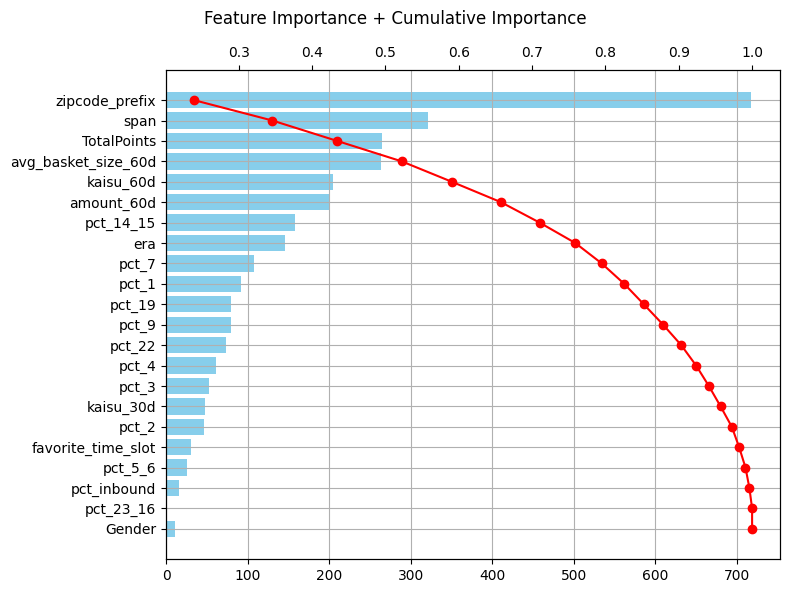

In [ ]:
# 特徴量の重要度をグラフ化
feature_importances = model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({'特徴量': feature_names, '重要度': feature_importances})
importance_df = importance_df.sort_values(by="重要度", ascending=False)
importance_df["重要度(%)"] = importance_df["重要度"] / importance_df["重要度"].sum()
importance_df["累積重要度"] = importance_df["重要度(%)"].cumsum()
importance_df = importance_df.sort_values(by="累積重要度", ascending=False)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.barh(
    importance_df["特徴量"],
    importance_df["重要度"],
    color="skyblue",
    label="Importance"
)
ax1.grid(True)

ax2 = ax1.twiny()
ax2.plot(
    importance_df["累積重要度"],
    importance_df["特徴量"],
    color="red",
    marker="o",
    label="Cumulative Importance"
)

# 凡例と仕上げ
fig.suptitle("Feature Importance + Cumulative Importance", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
dataset = "test"
table = "rihanyosoku_tashiro_output3"

df_output = X_test.copy()
df_output["score"] = y_pred
df_output["label"] = y_test.values
df_output["index"] = df_output.index

to_gbq(
    df_output,
    destination_table=f"{dataset}.{table}",
    project_id=project_id,
    if_exists="replace"
)

100%|██████████| 1/1 [00:00<00:00, 2153.13it/s]


### Case4 spanなし  


In [ ]:
df = df_copy.copy()
del df['span']

categorical_cols = [
    'favorite_time_slot',
    'zipcode_prefix',
    'era',
    'Gender',
    'store_last_visit',
    'store_most_visit'
]

# 特徴量とラベルを定義
X = df.drop('label', axis=1)
y = df['label']

# 1 アンダーサンプリングの実行
undersampler = RandomUnderSampler(sampling_strategy=0.5, random_state=42)  # 1:9 → 1:2 に調整
X_resampled, y_resampled = undersampler.fit_resample(X, y)

# 2 アンダーサンプリング後のデータ分布を確認
sampling_result = pd.DataFrame({'ラベル': ['0 (多数クラス)', '1 (少数クラス)'],
                                'データ数': [sum(y_resampled == 0), sum(y_resampled == 1)]})
# 3 データの分割**
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# 4 カテゴリ変数を指定
dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols)
dtest  = lgb.Dataset(X_test, label=y_test, reference=dtrain, categorical_feature=categorical_cols)

for col in categorical_cols:# カテゴリ列を明示的に category 型に変換
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# 5 LightGBM モデルの定義（不均衡データ対応）
model = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    random_state=42,
    n_estimators=100
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=10),
        lgb.log_evaluation(period=0)  # 表示抑制（0で非表示、10で10回ごと表示など）
    ],
    categorical_feature=categorical_cols
)

y_pred = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)
print(f"AUC: {auc:.4f}")
print('-----------')
y_pred_class = (y_pred >= 0.5).astype(int)
print(classification_report(y_test, y_pred_class))

[LightGBM] [Info] Number of positive: 105699, number of negative: 211485
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.057832 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4050
[LightGBM] [Info] Number of data points in the train set: 317184, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333242 -> initscore=-0.693559
[LightGBM] [Info] Start training from score -0.693559
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[99]	valid_0's auc: 0.873775
AUC: 0.8738
-----------
              precision    recall  f1-score   support

         0.0       0.85      0.85      0.85     52835
         1.0       0.70      0.71      0.70     26461

    accuracy                           0.80     79296
   macro avg       0.78      0.78      0.78     79296
weigh

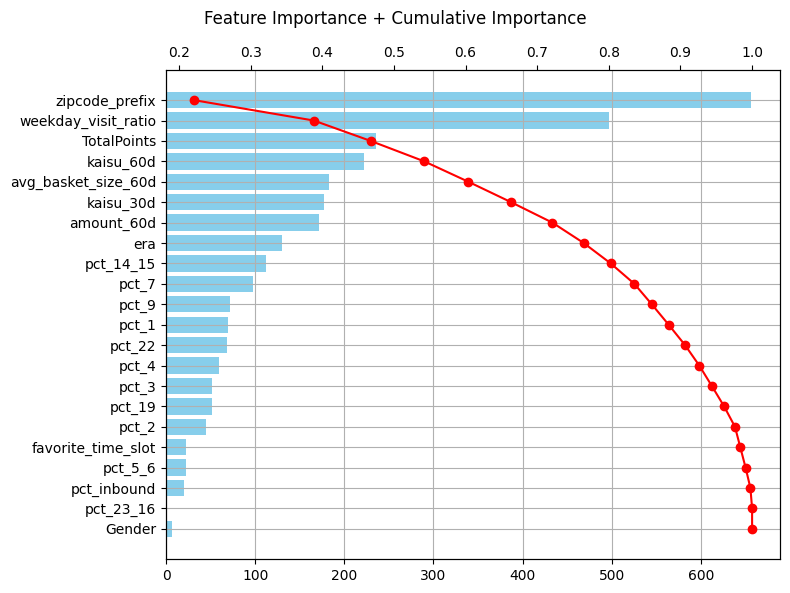

In [ ]:
# 特徴量の重要度をグラフ化
feature_importances = model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({'特徴量': feature_names, '重要度': feature_importances})
importance_df = importance_df.sort_values(by="重要度", ascending=False)
importance_df["重要度(%)"] = importance_df["重要度"] / importance_df["重要度"].sum()
importance_df["累積重要度"] = importance_df["重要度(%)"].cumsum()
importance_df = importance_df.sort_values(by="累積重要度", ascending=False)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.barh(
    importance_df["特徴量"],
    importance_df["重要度"],
    color="skyblue",
    label="Importance"
)
ax1.grid(True)

ax2 = ax1.twiny()
ax2.plot(
    importance_df["累積重要度"],
    importance_df["特徴量"],
    color="red",
    marker="o",
    label="Cumulative Importance"
)

# 凡例と仕上げ
fig.suptitle("Feature Importance + Cumulative Importance", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
dataset = "test"
table = "rihanyosoku_tashiro_output4"

df_output = X_test.copy()
df_output["score"] = y_pred
df_output["label"] = y_test.values
df_output["index"] = df_output.index

to_gbq(
    df_output,
    destination_table=f"{dataset}.{table}",
    project_id=project_id,
    if_exists="replace"
)

100%|██████████| 1/1 [00:00<00:00, 2270.87it/s]


### Case5 TotalPointsなし

In [ ]:
df = df_copy.copy()
del df['TotalPoints']

categorical_cols = [
    'favorite_time_slot',
    'zipcode_prefix',
    'era',
    'Gender',
    'store_last_visit',
    'store_most_visit'
]

# 特徴量とラベルを定義
X = df.drop('label', axis=1)
y = df['label']

# 1 アンダーサンプリングの実行
undersampler = RandomUnderSampler(sampling_strategy=0.5, random_state=42)  # 1:9 → 1:2 に調整
X_resampled, y_resampled = undersampler.fit_resample(X, y)

# 2 アンダーサンプリング後のデータ分布を確認
sampling_result = pd.DataFrame({'ラベル': ['0 (多数クラス)', '1 (少数クラス)'],
                                'データ数': [sum(y_resampled == 0), sum(y_resampled == 1)]})
# 3 データの分割**
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# 4 カテゴリ変数を指定
dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols)
dtest  = lgb.Dataset(X_test, label=y_test, reference=dtrain, categorical_feature=categorical_cols)

for col in categorical_cols:# カテゴリ列を明示的に category 型に変換
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# 5 LightGBM モデルの定義（不均衡データ対応）
model = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    random_state=42,
    n_estimators=100
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=10),
        lgb.log_evaluation(period=0)  # 表示抑制（0で非表示、10で10回ごと表示など）
    ],
    categorical_feature=categorical_cols
)

y_pred = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)
print(f"AUC: {auc:.4f}")
print('-----------')
y_pred_class = (y_pred >= 0.5).astype(int)
print(classification_report(y_test, y_pred_class))

[LightGBM] [Info] Number of positive: 105699, number of negative: 211485
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058368 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3886
[LightGBM] [Info] Number of data points in the train set: 317184, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333242 -> initscore=-0.693559
[LightGBM] [Info] Start training from score -0.693559
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[96]	valid_0's auc: 0.873794
AUC: 0.8738
-----------
              precision    recall  f1-score   support

         0.0       0.85      0.85      0.85     52835
         1.0       0.70      0.71      0.70     26461

    accuracy                           0.80     79296
   macro avg       0.78      0.78      0.78     79296
weigh

### Case6 kaisu_60dなし

In [ ]:
df = df_copy.copy()
del df['kaisu_60d']

categorical_cols = [
    'favorite_time_slot',
    'zipcode_prefix',
    'era',
    'Gender',
    'store_last_visit',
    'store_most_visit'
]

# 特徴量とラベルを定義
X = df.drop('label', axis=1)
y = df['label']

# 1 アンダーサンプリングの実行
undersampler = RandomUnderSampler(sampling_strategy=0.5, random_state=42)  # 1:9 → 1:2 に調整
X_resampled, y_resampled = undersampler.fit_resample(X, y)

# 2 アンダーサンプリング後のデータ分布を確認
sampling_result = pd.DataFrame({'ラベル': ['0 (多数クラス)', '1 (少数クラス)'],
                                'データ数': [sum(y_resampled == 0), sum(y_resampled == 1)]})
# 3 データの分割**
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# 4 カテゴリ変数を指定
dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols)
dtest  = lgb.Dataset(X_test, label=y_test, reference=dtrain, categorical_feature=categorical_cols)

for col in categorical_cols:# カテゴリ列を明示的に category 型に変換
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# 5 LightGBM モデルの定義（不均衡データ対応）
model = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    random_state=42,
    n_estimators=100
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=10),
        lgb.log_evaluation(period=0)  # 表示抑制（0で非表示、10で10回ごと表示など）
    ],
    categorical_feature=categorical_cols
)

y_pred = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)
print(f"AUC: {auc:.4f}")
print('-----------')
y_pred_class = (y_pred >= 0.5).astype(int)
print(classification_report(y_test, y_pred_class))

[LightGBM] [Info] Number of positive: 105699, number of negative: 211485
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.057557 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4082
[LightGBM] [Info] Number of data points in the train set: 317184, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333242 -> initscore=-0.693559
[LightGBM] [Info] Start training from score -0.693559
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[96]	valid_0's auc: 0.872794
AUC: 0.8728
-----------
              precision    recall  f1-score   support

         0.0       0.85      0.85      0.85     52835
         1.0       0.70      0.71      0.70     26461

    accuracy                           0.80     79296
   macro avg       0.77      0.78      0.77     79296
weigh

### Case7 上位3つ除外

In [ ]:
df = df_copy.copy()
delete_columns = importance_df1.sort_values(by="重要度", ascending=False)["特徴量"].head(3).tolist()
print(delete_columns)
df = df.drop(columns=delete_columns)

categorical_cols = [
    'favorite_time_slot',
    'zipcode_prefix',
    'era',
    'Gender',
#    'store_last_visit',
#    'store_most_visit'
]

# 特徴量とラベルを定義
X = df.drop('label', axis=1)
y = df['label']

# 1 アンダーサンプリングの実行
undersampler = RandomUnderSampler(sampling_strategy=0.5, random_state=42)  # 1:9 → 1:2 に調整
X_resampled, y_resampled = undersampler.fit_resample(X, y)

# 2 アンダーサンプリング後のデータ分布を確認
sampling_result = pd.DataFrame({'ラベル': ['0 (多数クラス)', '1 (少数クラス)'],
                                'データ数': [sum(y_resampled == 0), sum(y_resampled == 1)]})
# 3 データの分割**
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# 4 カテゴリ変数を指定
dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols)
dtest  = lgb.Dataset(X_test, label=y_test, reference=dtrain, categorical_feature=categorical_cols)

for col in categorical_cols:# カテゴリ列を明示的に category 型に変換
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# 5 LightGBM モデルの定義（不均衡データ対応）
model = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    random_state=42,
    n_estimators=100
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=10),
        lgb.log_evaluation(period=0)  # 表示抑制（0で非表示、10で10回ごと表示など）
    ],
    categorical_feature=categorical_cols
)

y_pred = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)
print(f"AUC: {auc:.4f}")
print('-----------')
y_pred_class = (y_pred >= 0.5).astype(int)
print(classification_report(y_test, y_pred_class))

['store_most_visit', 'store_last_visit', 'purchase_interval_std']
[LightGBM] [Info] Number of positive: 105699, number of negative: 211485
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.089844 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4619
[LightGBM] [Info] Number of data points in the train set: 317184, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333242 -> initscore=-0.693559
[LightGBM] [Info] Start training from score -0.693559
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's auc: 0.882783
AUC: 0.8828
-----------
              precision    recall  f1-score   support

         0.0       0.86      0.85      0.85     52835
         1.0       0.70      0.72      0.71     26461

    accuracy                           0.81   

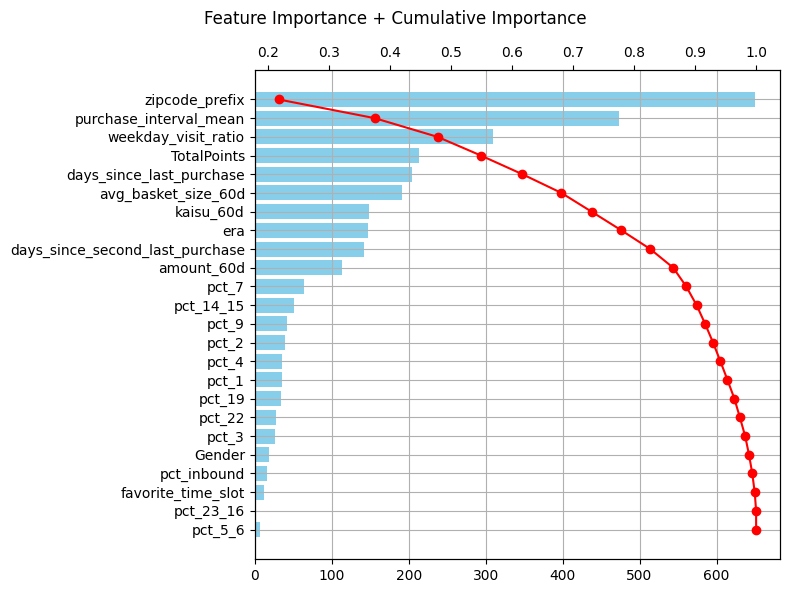

In [ ]:
# 特徴量の重要度をグラフ化
feature_importances = model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({'特徴量': feature_names, '重要度': feature_importances})
importance_df = importance_df.sort_values(by="重要度", ascending=False)
importance_df["重要度(%)"] = importance_df["重要度"] / importance_df["重要度"].sum()
importance_df["累積重要度"] = importance_df["重要度(%)"].cumsum()
importance_df = importance_df.sort_values(by="累積重要度", ascending=False)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.barh(
    importance_df["特徴量"],
    importance_df["重要度"],
    color="skyblue",
    label="Importance"
)
ax1.grid(True)

ax2 = ax1.twiny()
ax2.plot(
    importance_df["累積重要度"],
    importance_df["特徴量"],
    color="red",
    marker="o",
    label="Cumulative Importance"
)

# 凡例と仕上げ
fig.suptitle("Feature Importance + Cumulative Importance", fontsize=12)
plt.tight_layout()
plt.show()

### Case8 上位5つのみ  
['zipcode_prefix', 'weekday_visit_ratio', 'span', 'TotalPoints', 'kaisu_60d']  
郵便番号、平日来店比率、最終来店日からの経過日数、ポイント数(エゾカに慣れてるかどうか？)、来店頻度

In [ ]:
df = df_copy.copy()
cols = importance_df1.sort_values(by="重要度", ascending=False)["特徴量"].head(5).tolist()
print(cols)
df = df[cols+['label']]

categorical_cols = [
#    'favorite_time_slot',
#    'zipcode_prefix',
#    'era',
#    'Gender',
    'store_last_visit',
    'store_most_visit'
]

# 特徴量とラベルを定義
X = df.drop('label', axis=1)
y = df['label']

# 1 アンダーサンプリングの実行
undersampler = RandomUnderSampler(sampling_strategy=0.5, random_state=42)  # 1:9 → 1:2 に調整
X_resampled, y_resampled = undersampler.fit_resample(X, y)

# 2 アンダーサンプリング後のデータ分布を確認
sampling_result = pd.DataFrame({'ラベル': ['0 (多数クラス)', '1 (少数クラス)'],
                                'データ数': [sum(y_resampled == 0), sum(y_resampled == 1)]})
# 3 データの分割**
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# 4 カテゴリ変数を指定
dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols)
dtest  = lgb.Dataset(X_test, label=y_test, reference=dtrain, categorical_feature=categorical_cols)

for col in categorical_cols:# カテゴリ列を明示的に category 型に変換
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# 5 LightGBM モデルの定義（不均衡データ対応）
model = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    random_state=42,
    n_estimators=100
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=10),
        lgb.log_evaluation(period=0)  # 表示抑制（0で非表示、10で10回ごと表示など）
    ],
    categorical_feature=categorical_cols
)

y_pred = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)
print(f"AUC: {auc:.4f}")
print('-----------')
y_pred_class = (y_pred >= 0.5).astype(int)
print(classification_report(y_test, y_pred_class))

['store_most_visit', 'store_last_visit', 'purchase_interval_std', 'days_since_last_purchase', 'weekday_visit_ratio']
[LightGBM] [Info] Number of positive: 105699, number of negative: 211485
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.029245 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1055
[LightGBM] [Info] Number of data points in the train set: 317184, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333242 -> initscore=-0.693559
[LightGBM] [Info] Start training from score -0.693559
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[54]	valid_0's auc: 0.877844
AUC: 0.8778
-----------
              precision    recall  f1-score   support

         0.0       0.85      0.85      0.85     52835
         1.0       0.70      0.71      0.71     26461

    accuracy                           0.80     79296
   macro avg       0

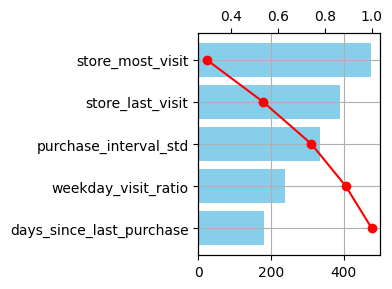

In [ ]:
# 特徴量の重要度をグラフ化
feature_importances = model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({'特徴量': feature_names, '重要度': feature_importances})
importance_df = importance_df.sort_values(by="重要度", ascending=False)
importance_df["重要度(%)"] = importance_df["重要度"] / importance_df["重要度"].sum()
importance_df["累積重要度"] = importance_df["重要度(%)"].cumsum()
importance_df = importance_df.sort_values(by="累積重要度", ascending=False)

fig, ax1 = plt.subplots(figsize=(4, 3))

ax1.barh(
    importance_df["特徴量"],
    importance_df["重要度"],
    color="skyblue",
    label="Importance"
)
ax1.grid(True)

ax2 = ax1.twiny()
ax2.plot(
    importance_df["累積重要度"],
    importance_df["特徴量"],
    color="red",
    marker="o",
    label="Cumulative Importance"
)
plt.tight_layout()
plt.show()

In [ ]:
dataset = "test"
table = "rihanyosoku_tashiro_output8"

df_output = X_test.copy()
df_output["score"] = y_pred
df_output["label"] = y_test.values
df_output["index"] = df_output.index

to_gbq(
    df_output,
    destination_table=f"{dataset}.{table}",
    project_id=project_id,
    if_exists="replace"
)

100%|██████████| 1/1 [00:00<00:00, 9383.23it/s]


### Case9 last_visit_storeなし

In [ ]:
df = df_copy.copy()
del df['store_last_visit']

categorical_cols = [
    'favorite_time_slot',
    'zipcode_prefix',
    'era',
    'Gender',
#    'store_last_visit',
    'store_most_visit'
]

# 特徴量とラベルを定義
X = df.drop('label', axis=1)
y = df['label']

# 1 アンダーサンプリングの実行
undersampler = RandomUnderSampler(sampling_strategy=0.5, random_state=42)  # 1:9 → 1:2 に調整
X_resampled, y_resampled = undersampler.fit_resample(X, y)

# 2 アンダーサンプリング後のデータ分布を確認
sampling_result = pd.DataFrame({'ラベル': ['0 (多数クラス)', '1 (少数クラス)'],
                                'データ数': [sum(y_resampled == 0), sum(y_resampled == 1)]})
# 3 データの分割**
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# 4 カテゴリ変数を指定
dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols)
dtest  = lgb.Dataset(X_test, label=y_test, reference=dtrain, categorical_feature=categorical_cols)

for col in categorical_cols:# カテゴリ列を明示的に category 型に変換
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# 5 LightGBM モデルの定義（不均衡データ対応）
model = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    random_state=42,
    n_estimators=100
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=10),
        lgb.log_evaluation(period=0)  # 表示抑制（0で非表示、10で10回ごと表示など）
    ],
    categorical_feature=categorical_cols
)

y_pred = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)
print(f"AUC: {auc:.4f}")
print('-----------')
y_pred_class = (y_pred >= 0.5).astype(int)
print(classification_report(y_test, y_pred_class))

[LightGBM] [Info] Number of positive: 105699, number of negative: 211485
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.093371 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5101
[LightGBM] [Info] Number of data points in the train set: 317184, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333242 -> initscore=-0.693559
[LightGBM] [Info] Start training from score -0.693559
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[91]	valid_0's auc: 0.886141
AUC: 0.8861
-----------
              precision    recall  f1-score   support

         0.0       0.86      0.85      0.86     52835
         1.0       0.71      0.72      0.72     26461

    accuracy                           0.81     79296
   macro avg       0.78      0.79      0.79     79296
weigh

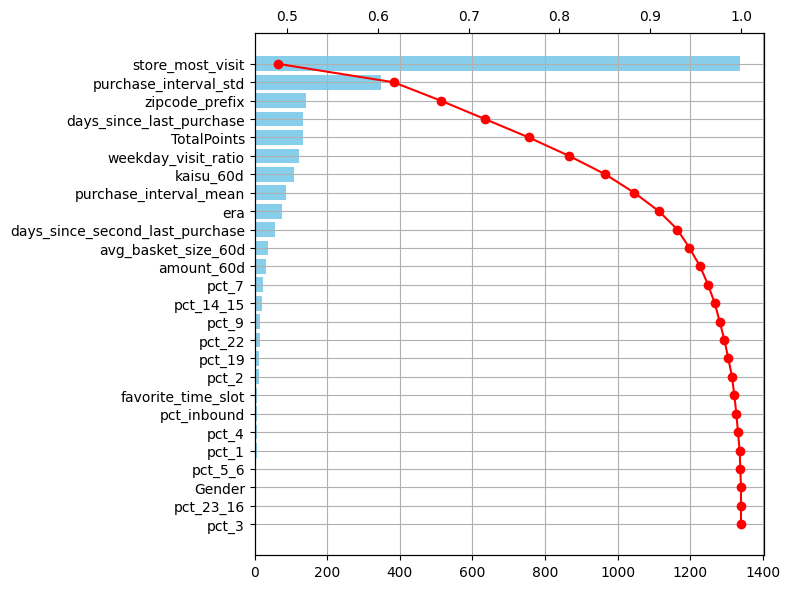

In [ ]:
# 特徴量の重要度をグラフ化
feature_importances = model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({'特徴量': feature_names, '重要度': feature_importances})
importance_df = importance_df.sort_values(by="重要度", ascending=False)
importance_df["重要度(%)"] = importance_df["重要度"] / importance_df["重要度"].sum()
importance_df["累積重要度"] = importance_df["重要度(%)"].cumsum()
importance_df = importance_df.sort_values(by="累積重要度", ascending=False)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.barh(
    importance_df["特徴量"],
    importance_df["重要度"],
    color="skyblue",
    label="Importance"
)
ax1.grid(True)

ax2 = ax1.twiny()
ax2.plot(
    importance_df["累積重要度"],
    importance_df["特徴量"],
    color="red",
    marker="o",
    label="Cumulative Importance"
)
plt.tight_layout()
plt.show()